In [77]:
import os
import glob

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from matplotlib import pyplot as plt
import open3d as o3d
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
import pandas as pd
from joblib import Parallel, delayed
import random
tf.random.set_seed(1234)

In [79]:
# ============================================================
# 1. CONFIGURATION
# ============================================================
STABLE_LIST = ['419', '453', '458', '467', '472', '485', '492', '495', '542-533']
CLASS_TO_SOW = {sow: idx for idx, sow in enumerate(STABLE_LIST)}

# Path to the log CSV created in the previous step
VISIT_LOG_CSV = r"C:\Users\spaudel\OneDrive - University of Arkansas System Division of Agriculture\Desktop\Projects_shivapdl\ID_Organized_CVPR\Output_Logs\2_Day3_1500\visit_level_logs_Day3_1_10sows.csv"
NUM_POINTS = 1500
N_JOBS = 22
MAX_FILES_PER_CLASS = 200  # Caps total frames per pig to keep memory stable
MIN_FILE_KB = 200
MIN_FILE_BYTES = MIN_FILE_KB * 1024

# ============================================================
# 2. FILE PROCESSING (PointNet Preprocessing)
# ============================================================

In [80]:


# ============================================================
# 1. PROCESSING FUNCTION
# ============================================================
def process_one_file(full_path, label_index):
    """Processes a single PLY: Voxel downsample, sample fixed points, normalize."""
    try:
        # Check size to skip corrupted or tiny files
        if not os.path.exists(full_path) or os.path.getsize(full_path) < MIN_FILE_BYTES:
            return None, None

        pcd = o3d.io.read_point_cloud(full_path)
        
        # Match training voxel size
        pcd = pcd.voxel_down_sample(voxel_size=0.005)
        pts = np.asarray(pcd.points)
        
        if pts.shape[0] < NUM_POINTS:
            return None, None

        # Random sampling to fixed point count
        idx = np.random.choice(pts.shape[0], NUM_POINTS, replace=False)
        sampled = pts[idx]

        # Unit sphere normalization
        centroid = np.mean(sampled, axis=0)
        sampled = sampled - centroid
        dist = np.max(np.sqrt(np.sum(sampled**2, axis=1)))
        if dist > 0:
            sampled = sampled / dist

        return sampled.astype(np.float32), label_index
    except Exception:
        return None, None

# ============================================================
# 2. LOG-BASED DATASET PARSER
# ============================================================
def parse_dataset_from_logs(csv_path):
    """
    Reads the visit CSV. 
    Filters for Successful visits matching the STABLE_LIST IDs.
    """
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"❌ Log file not found at: {csv_path}")

    # Read log
    df = pd.read_csv(csv_path)
    
    # Standardize ID and Status strings
    df['Predicted_SowID'] = df['Predicted_SowID'].astype(str).str.strip()
    df['Status'] = df['Status'].astype(str).str.strip()

    # 🛑 FILTER: Only keep successful visits for IDs in our STABLE_LIST
    # This automatically ignores "N/A" because it won't be in STABLE_LIST
    df_valid = df[
        (df['Predicted_SowID'].isin(STABLE_LIST)) & 
        (df['Status'] == 'SUCCESS')
    ].copy()

    print(f"📊 Total visits in log: {len(df)}")
    print(f"✅ Successful visits for target Sows: {len(df_valid)}")
    print("--- Breakdown per Sow (Valid Frames) ---")
    print(df_valid.groupby('Predicted_SowID')['ValidFrames'].sum())

    # Map directories to their predicted labels
    class_files = {sow: [] for sow in STABLE_LIST}

    for _, row in df_valid.iterrows():
        visit_dir = row['Directory']
        sow_id = row['Predicted_SowID']
        
        if not os.path.isdir(visit_dir):
            # Useful for debugging path issues
            # print(f"⚠️ Path not found: {visit_dir}")
            continue

        # Find all PLY files in this visit folder
        files = [os.path.join(visit_dir, f) for f in os.listdir(visit_dir) 
                 if f.lower().endswith(".ply")]
        
        class_files[sow_id].extend(files)

    # Prepare parallel jobs
    jobs = []
    for sow_id, files in class_files.items():
        if not files:
            continue
            
        label_idx = CLASS_TO_SOW[sow_id]
        
        # Sample files if they exceed the maximum allowed per class
        if len(files) > MAX_FILES_PER_CLASS:
            selected_files = random.sample(files, MAX_FILES_PER_CLASS)
        else:
            selected_files = files
            
        for f in selected_files:
            jobs.append((f, label_idx))

    if not jobs:
        print("❌ No files found to process!")
        return None, None, None, None

    print(f"\n🚀 Processing {len(jobs)} total frames using {N_JOBS} cores...")

    # Run Parallel Processing
    results = Parallel(n_jobs=N_JOBS, prefer="processes")(
        delayed(process_one_file)(path, lbl) for path, lbl in jobs
    )

    # Collect results
    final_points, final_labels = [], []
    for sample, label in results:
        if sample is not None:
            final_points.append(sample)
            final_labels.append(label)

    if len(final_points) == 0:
        print("❌ No usable samples survived processing!")
        return None, None, None, None

    # Convert to NumPy arrays
    data_points = np.array(final_points)
    data_labels = to_categorical(np.array(final_labels), num_classes=len(STABLE_LIST))

    # 3. TRAIN/VAL SPLIT
    train_pts, val_pts, train_lbl, val_lbl = train_test_split(
        data_points, 
        data_labels, 
        test_size=0.2, 
        random_state=42, 
        stratify=final_labels 
    )

    print(f"\n--- Loading Complete ---")
    print(f"Final Data Shape: {data_points.shape}")
    print(f"Training Set: {train_pts.shape}")
    print(f"Validation Set: {val_pts.shape}")

    return train_pts, train_lbl, val_pts, val_lbl

In [81]:
train_points, train_labels, test_points, test_labels = parse_dataset_from_logs(VISIT_LOG_CSV)

📊 Total visits in log: 285
✅ Successful visits for target Sows: 117
--- Breakdown per Sow (Valid Frames) ---
Predicted_SowID
419        238
453         55
458        555
467        297
472        822
485         93
492        211
495        219
542-533    902
Name: ValidFrames, dtype: int64

🚀 Processing 1692 total frames using 22 cores...

--- Loading Complete ---
Final Data Shape: (1518, 1500, 3)
Training Set: (1214, 1500, 3)
Validation Set: (304, 1500, 3)


In [82]:
def augment(points, label):
    points = tf.cast(points, tf.float32)            # ensure float32
    noise = tf.random.normal(tf.shape(points), mean=0.0, stddev=0.007, dtype=points.dtype)
    points = points + noise
    points = tf.random.shuffle(points)
    return points, label


In [83]:

num_classes = train_labels.shape[1]
print(num_classes)

train_dataset = tf.data.Dataset.from_tensor_slices((train_points, train_labels))
test_dataset = tf.data.Dataset.from_tensor_slices((test_points, test_labels))
train_dataset = train_dataset.shuffle(len(train_points)).map(augment).batch(32)
test_dataset = test_dataset.shuffle(len(test_points)).batch(32)


9


In [84]:
def conv_bn(x, filters):
    x = layers.Conv1D(filters, kernel_size=1, padding="valid")(x)
    x = layers.BatchNormalization(momentum=0.0)(x)
    return layers.Activation("relu")(x)


def dense_bn(x, filters):
    x = layers.Dense(filters)(x)
    x = layers.BatchNormalization(momentum=0.0)(x)
    return layers.Activation("relu")(x)

In [85]:
class OrthogonalRegularizer(keras.regularizers.Regularizer):
    def __init__(self, num_features, l2reg=0.001):
        self.num_features = num_features
        self.l2reg = l2reg
        self.eye = tf.eye(num_features)

    def __call__(self, x):
        x = tf.reshape(x, (-1, self.num_features, self.num_features))
        xxt = tf.tensordot(x, x, axes=(2, 2))
        xxt = tf.reshape(xxt, (-1, self.num_features, self.num_features))
        return tf.reduce_sum(self.l2reg * tf.square(xxt - self.eye))

In [86]:
def tnet(inputs, num_features):

    # Initalise bias as the indentity matrix
    bias = keras.initializers.Constant(np.eye(num_features).flatten())
    reg = OrthogonalRegularizer(num_features)

    x = conv_bn(inputs, 32)
    x = conv_bn(x, 64)
    x = conv_bn(x, 512)
    x = layers.GlobalMaxPooling1D()(x)
    x = dense_bn(x, 256)
    x = dense_bn(x, 128)
    x = layers.Dense(
        num_features * num_features,
        kernel_initializer="zeros",
        bias_initializer=bias,
        activity_regularizer=reg,
    )(x)
    feat_T = layers.Reshape((num_features, num_features))(x)
    # Apply affine transformation to input features
    return layers.Dot(axes=(2, 1))([inputs, feat_T])

In [87]:
inputs = keras.Input(shape=(1500, 3))

x = tnet(inputs, 3)
x = conv_bn(x, 32)
x = conv_bn(x, 64)
x = tnet(x, 64)
x = conv_bn(x, 128)
x = conv_bn(x, 128)
x = conv_bn(x, 256)


feature_layer = x   # <<<<<< HERE

x = layers.GlobalMaxPooling1D()(x)
x = dense_bn(x, 128)
x = layers.Dropout(0.1)(x)
x = dense_bn(x, 128)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)
model.load_weights(r"C:\Users\spaudel\OneDrive - University of Arkansas System Division of Agriculture\Desktop\Projects_shivapdl\ID_Organized_CVPR\Weights\Weight_9_2\9pig_Day2_1500.h5")

In [88]:

initial_learning_rate = 0.001
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=10000,
    decay_rate=0.5,
    staircase=True
)

model.compile(
    loss="categorical_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    metrics=["categorical_accuracy"],
)

early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=15,
    restore_best_weights=True,
)

history = model.fit(
    train_dataset,
    epochs=200,
    validation_data=test_dataset,
    callbacks=[early_stop_cb],
)


Epoch 1/200
38/38 [==============================] - 7s 99ms/step - loss: 2.6371 - categorical_accuracy: 0.8814 - val_loss: 2.4539 - val_categorical_accuracy: 0.9145
Epoch 2/200
38/38 [==============================] - 3s 85ms/step - loss: 2.4229 - categorical_accuracy: 0.9102 - val_loss: 2.3850 - val_categorical_accuracy: 0.9342
Epoch 3/200
38/38 [==============================] - 3s 86ms/step - loss: 2.3645 - categorical_accuracy: 0.9242 - val_loss: 2.3190 - val_categorical_accuracy: 0.9243
Epoch 4/200
38/38 [==============================] - 3s 86ms/step - loss: 2.2931 - categorical_accuracy: 0.9432 - val_loss: 2.1963 - val_categorical_accuracy: 0.9671
Epoch 5/200
38/38 [==============================] - 3s 85ms/step - loss: 2.2771 - categorical_accuracy: 0.9489 - val_loss: 2.2089 - val_categorical_accuracy: 0.9539
Epoch 6/200
38/38 [==============================] - 3s 85ms/step - loss: 2.3574 - categorical_accuracy: 0.9333 - val_loss: 2.4382 - val_categorical_accuracy: 0.9013
Epoc

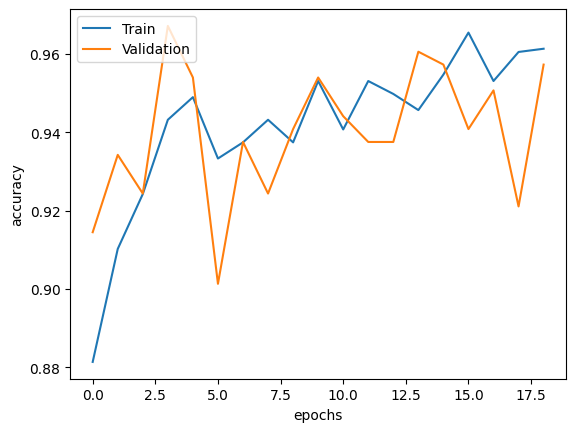

In [89]:
# from matplotlib import pyplot as plt
plt.plot(history.history['categorical_accuracy'])
plt.plot(history.history['val_categorical_accuracy'])
# plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.legend(['Train', 'Validation'], loc='upper left')
# plt.savefig('learning_curvepng')

1/1 [==============================] - 0s 313ms/step


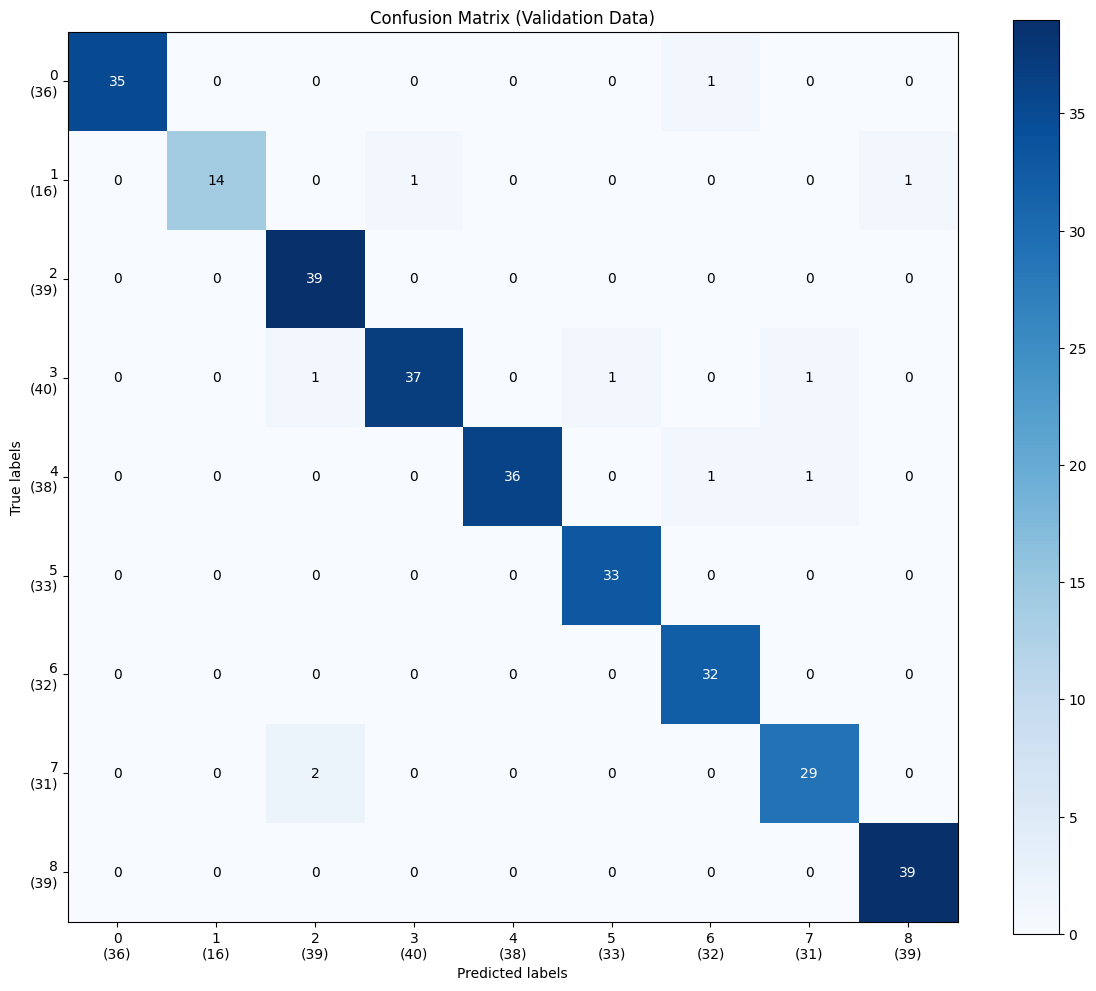

In [90]:
preds = []
true_labels = []
for val_batch, val_label_batch in test_dataset:
    pred_batch = model.predict(val_batch)
    preds.extend(np.argmax(pred_batch, axis=-1))
    true_labels.extend(np.argmax(val_label_batch, axis=-1))

# Convert lists to numpy arrays
preds = np.array(preds)
true_labels = np.array(true_labels)

# Calculate confusion matrix
cm = confusion_matrix(true_labels, preds)

# Calculate total number of images for each class
class_counts = np.sum(cm, axis=1)
num_classes = len(class_counts)  # Get the number of classes from class_counts

# Plot confusion matrix with class counts as tick labels
plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Validation Data)')
plt.colorbar()
tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, [f'{i}\n({count})' for i, count in enumerate(class_counts)])
plt.yticks(tick_marks, [f'{i}\n({count})' for i, count in enumerate(class_counts)])

# Annotate confusion matrix cells with counts
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, "{:d}".format(cm[i, j]),
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.tight_layout()
plt.show()

In [91]:
model.save_weights(r"C:\Users\spaudel\OneDrive - University of Arkansas System Division of Agriculture\Desktop\Projects_shivapdl\ID_Organized_CVPR\Weights\Weight_9_2\9pig_Day32_1500.h5")